In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

In [ ]:
# 1. Build a toy "dataset" X with shape (N, 3) and base weights w0

N = 10_000

# For demonstration: X is just some 3D Gaussian-ish cloud
X = rng.normal(loc=0.0, scale=1.0, size=(N, 3))

# Base event weights in [1, 10]
w0 = rng.uniform(1.0, 10.0, size=N)


# ----------------------------------------------------------------------
# 2. Define a reweighting function R(x, c)
#    w(c) = R(x; c) * w0
#
# Here we make something simple: R depends only on x[:, 0]
# e.g. R = exp(c * x0), which will emphasize large x0 for c > 0
# ----------------------------------------------------------------------
def R(x, c):
    """
    x: array of shape (N, 3)
    c: scalar parameter
    returns: array of shape (N,) with positive reweighting factors
    """
    x0 = x[:, 0]
    return np.exp(c * x0)


def compute_weights(x, w_nominal, c):
    """Compute new weights w(c) = R(x; c) * w_nominal."""
    r = R(x, c)
    w = r * w_nominal
    # Avoid numerical issues from negativity (shouldn't happen here)
    w = np.clip(w, 0.0, None)
    return w

In [3]:
# 3. Generic sampler: sample M events from X with given weights w
#    i.e. "discrete multidimensional pmf" sampler

def sample_events(X, w, M, rng=None):
    """
    X: array of shape (N, d)
    w: array of shape (N,)
    M: number of events to sample
    returns: X_sample of shape (M, d)
    """
    if rng is None:
        rng = np.random.default_rng()
    
    w = np.asarray(w, dtype=float)
    total = w.sum()
    if total <= 0:
        raise ValueError("Sum of weights is non-positive; cannot build probabilities.")

    p = w / total  # probabilities for each event

    # Draw indices with replacement according to probabilities p
    indices = rng.choice(len(w), size=M, replace=True, p=p)
    return X[indices]

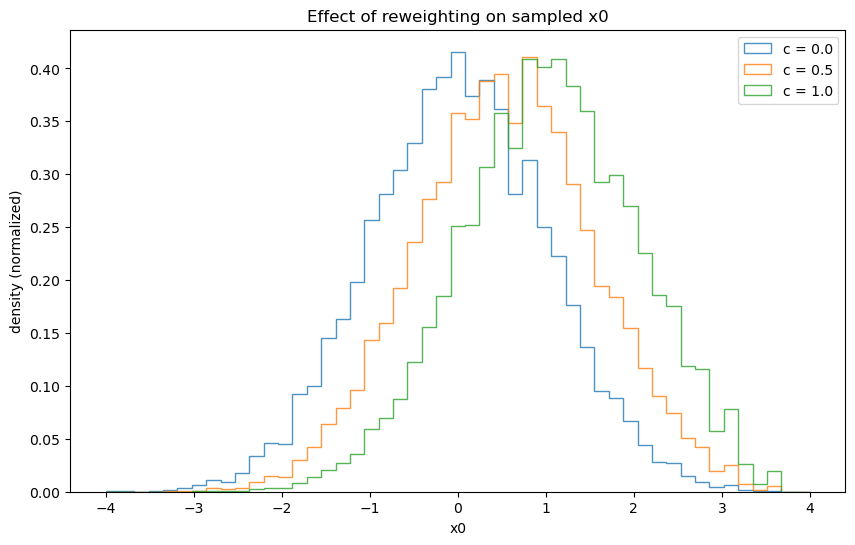

In [5]:
# 4. Test the sampling for different c values

M = 50_000  # number of toy events to generate

# Case A: c = 0  -> w(c) = w0 (no reweighting except base weights)
c_values = [0.0, 0.5, 1.0]

# Prepare a figure to see effect on the first coordinate x0
plt.figure(figsize=(10, 6))

bins = np.linspace(-4, 4, 50)

for c in c_values:
    w_c = compute_weights(X, w0, c)
    X_sample = sample_events(X, w_c, M, rng=rng)
    x0_sample = X_sample[:, 0]
    plt.hist(
        x0_sample,
        bins=bins,
        histtype='step',
        density=True,
        label=f"c = {c}",
        alpha=0.8,
    )

plt.title("Effect of reweighting on sampled x0")
plt.xlabel("x0")
plt.ylabel("density (normalized)")
plt.legend()
# plt.grid(True)
plt.show()
